# Supplementary experiments: lookback length and seed stability

This notebook contains the code behind **Figure 9** (lookback window 1 to 30 days) and
**Figure 10** (seed stability), plus **Table B7** and **Table B8**. Neither experiment lives in
`final_stock_code.ipynb`, which is exactly why the report was open to the criticism that the
figures were not reproducible from the code. Adding this notebook to the submission closes that gap.

Everything upstream of model construction is copied cell for cell from `final_stock_code.ipynb`:
same cleaning, same `target = close.shift(-1)`, same chronological 75/25 split, same MinMaxScalers
fitted on train only, same LSTM and BiLSTM architectures. Only two things change, one per
experiment: the lookback window, and the random seed.

**Contents**

1. Setup and shared pipeline (copied from the main notebook)
2. Experiment A: seed stability, 5 seeds x 2 architectures x 5 stocks = 50 fits -> Figure 10, Table B8
3. Experiment B: lookback sweep, 8 windows x 3 seeds x 2 architectures x 5 stocks = 240 fits -> Figure 9, Table B7

**Two ways to run this.** The config cell has a `RERUN` switch.

- `RERUN = False` (how this notebook is saved) loads the result CSVs in `supplementary_results/`,
  which are the exact runs behind Figures 9 and 10 in the report. Every cell runs in seconds and the
  figures below match the report. Use this if you just want the plots and the tables.
- `RERUN = True` retrains everything from the CSVs in `Datasets10/`. Experiment A is 50 fits, about
  2 minutes. Experiment B is 240 fits, roughly 30 minutes, the long windows being the slow ones.

Both experiments are read-only with respect to `Datasets10/`. Anything written goes to `OUT_DIR`.

## 1. Setup and shared pipeline

Point `DATA_DIR` at the folder holding the five stock CSVs, `RESULTS_DIR` at the folder of saved
results shipped with this notebook, and `OUT_DIR` at wherever you want new files written. Everything
else in this section is lifted straight from the main notebook, with the cell number noted in each
docstring so you can check it against your own code.

The training functions are defined either way, so the pipeline is there to read even when
`RERUN = False`.

In [12]:
%matplotlib inline

import json
import os
import pathlib
import random

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


In [14]:
# ---- paths and run mode: change these to match your machine --------------------------------------
# folder with Reliance.csv, Infosys.csv, ... set it explicitly if the guess below is wrong
DATA_DIR = next((c for c in (pathlib.Path("Datasets10"),
                             pathlib.Path("all_files/Datasets10"),
                             pathlib.Path("../Datasets10")) if c.exists()),
                pathlib.Path("Datasets10"))
OUT_DIR = pathlib.Path("supplementary_output")     # anything this notebook writes goes here
RESULTS_DIR = pathlib.Path("supplementary_results")  # the result CSVs behind the report figures

# False: load the result CSVs used for the report, so the figures below are the ones in the report.
# True:  retrain everything from scratch, about 35 minutes for both experiments.
RERUN = False

OUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 200

FEATURES = ["open", "high", "low", "close", "volume"]
STOCKS = {
    "Reliance": "Reliance.csv",
    "Infosys": "Infosys.csv",
    "HDFC Bank": "HDFC_Bank.csv",
    "Maruti": "Maruti.csv",
    "Sun Pharma": "Sun_Pharma.csv",
}

if RERUN:
    assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR.resolve()}"
    missing = [f for f in STOCKS.values() if not (DATA_DIR / f).exists()]
    assert not missing, f"missing CSVs in {DATA_DIR.resolve()}: {missing}"

print(f"RERUN  = {RERUN}")
print(f"data   : {DATA_DIR.resolve()}")
print(f"results: {RESULTS_DIR.resolve()}")
print(f"out    : {OUT_DIR.resolve()}")

RERUN  = False
data   : C:\Users\SAI\Desktop\ds_project_stock_price_prediction\Datasets10
results: C:\Users\SAI\Desktop\ds_project_stock_price_prediction\supplementary_results
out    : C:\Users\SAI\Desktop\ds_project_stock_price_prediction\supplementary_output


In [15]:
def seed_everything(seed):
    """Main notebook cell 4, parameterised so the same configuration can be repeated."""
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)


def load_clean(csv_name):
    """Main notebook cell 10 - identical cleaning."""
    data = pd.read_csv(DATA_DIR / csv_name)
    data.columns = ["date", "close", "high", "low", "open", "volume"]
    data = data.iloc[2:].copy()                       # drop the two Yahoo metadata rows
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    for column in FEATURES:
        data[column] = pd.to_numeric(data[column], errors="coerce")
    data.dropna(subset=["date"] + FEATURES, inplace=True)
    data.sort_values("date", inplace=True)
    data.drop_duplicates(subset="date", inplace=True)
    data.set_index("date", inplace=True)
    return data


def split_and_scale(data):
    """Main notebook cells 40, 43, 46, 49 - target, chronological split, train-fitted scalers."""
    model_data = data.copy()
    model_data["target"] = model_data["close"].shift(-1)
    model_data.dropna(subset=["target"], inplace=True)

    X = model_data[FEATURES]
    y = model_data["target"]

    split_index = int(len(X) * 0.75)                  # no shuffle: the split is chronological
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    feature_scaler = MinMaxScaler()
    X_train_s = feature_scaler.fit_transform(X_train)
    X_test_s = feature_scaler.transform(X_test)       # transform only, no leakage from test

    target_scaler = MinMaxScaler()
    y_train_s = target_scaler.fit_transform(np.array(y_train).reshape(-1, 1))
    y_test_s = target_scaler.transform(np.array(y_test).reshape(-1, 1))

    return X_train_s, X_test_s, y_train_s, y_test_s, target_scaler


def make_sequences(X_s, y_s, window):
    """Main notebook cell 81, generalised from window_size = 1 to any window length."""
    Xs, ys = [], []
    for i in range(window, len(X_s)):
        Xs.append(X_s[i - window:i])
        ys.append(y_s[i])
    return np.array(Xs), np.array(ys)


def build_lstm(shape):
    """Main notebook cell 83 - baseline LSTM architecture, unchanged."""
    return Sequential([
        LSTM(64, return_sequences=True, input_shape=shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1),
    ])


def build_bilstm(shape):
    """Main notebook cell 105 - baseline BiLSTM architecture, unchanged."""
    return Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=shape),
        Dropout(0.2),
        Bidirectional(LSTM(32)),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1),
    ])


def evaluate(y_true, y_pred):
    """Main notebook cell 84 - same five metrics."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "R2": r2_score(y_true, y_pred),
    }


def fit_and_score(builder, shape, X_tr, y_tr, X_te, y_true, tscaler):
    """One fit with the notebook's training settings, scored in rupees rather than scaled units."""
    model = builder(shape)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.2, epochs=100, batch_size=32,
        callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
        verbose=0,
    )
    pred_s = model.predict(X_te, verbose=0).flatten()
    y_pred = tscaler.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    metrics = evaluate(y_true, y_pred)
    metrics["Epochs Run"] = len(history.history["loss"])
    return metrics


ARCHITECTURES = (("LSTM", build_lstm), ("BiLSTM", build_bilstm))
print("pipeline ready")

pipeline ready


## 2. Experiment A: seed stability (Figure 10, Table B8)

**The question this answers.** The main notebook trains each deep model once. Comparing LSTM against
tuned LSTM against BiLSTM against tuned BiLSTM on single fits is only meaningful if the gap between
them is bigger than the spread you get from rerunning the *same* architecture with a different seed.
This measures that spread: baseline LSTM and BiLSTM, window 1, five seeds, all five stocks.

It is what lets the report say that hyperparameter tuning changing almost nothing is not a
surprising result, and that "BiLSTM beat LSTM on 3 of 5 stocks" is not a finding. It is also the
reason Experiment B runs three seeds per point instead of one.

50 fits, about 2 minutes when `RERUN = True`. Otherwise the saved results load instantly.

In [16]:
SEED_STABILITY_SEEDS = [16, 42, 101, 2024, 7]
SEED_STABILITY_WINDOW = 1

_cached = RESULTS_DIR / "seed_stability_results.csv"

if not RERUN and _cached.exists():
    seed_df = pd.read_csv(_cached)
    print(f"loaded {len(seed_df)} fits from {_cached}")
    print("these are the runs behind Figure 10 in the report")
    print("set RERUN = True in the config cell to train from scratch instead")
else:
  rows = []
  for stock, csv_name in STOCKS.items():
      data = load_clean(csv_name)
      X_tr_s, X_te_s, y_tr_s, y_te_s, tscaler = split_and_scale(data)
      X_tr, y_tr = make_sequences(X_tr_s, y_tr_s, SEED_STABILITY_WINDOW)
      X_te, y_te = make_sequences(X_te_s, y_te_s, SEED_STABILITY_WINDOW)
      shape = (X_tr.shape[1], X_tr.shape[2])
      y_true = tscaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

      for arch, builder in ARCHITECTURES:
          for seed in SEED_STABILITY_SEEDS:
              seed_everything(seed)
              m = fit_and_score(builder, shape, X_tr, y_tr, X_te, y_true, tscaler)
              m.update({"Stock": stock, "Model": arch, "Seed": seed})
              rows.append(m)
              print(f"{stock:<11} {arch:<7} seed={seed:<5} RMSE={m['RMSE']:10.4f}  R2={m['R2']:8.4f}",
                    flush=True)

  seed_df = pd.DataFrame(rows)[["Stock", "Model", "Seed", "MAE", "MSE", "RMSE", "MAPE", "R2"]]
  seed_df.to_csv(OUT_DIR / "seed_stability_results.csv", index=False)
  print(f"\nwrote {OUT_DIR / 'seed_stability_results.csv'}")

loaded 50 fits from supplementary_results\seed_stability_results.csv
these are the runs behind Figure 10 in the report
set RERUN = True in the config cell to train from scratch instead


### Table B8: RMSE spread across the five seeds

`Spread (% of median)` is the number the report quotes. Anything large here means single-fit
comparisons between architectures in the main notebook cannot be trusted at that resolution.

In [17]:
seed_summary = (
    seed_df.groupby(["Stock", "Model"])["RMSE"]
           .agg(Min="min", Median="median", Max="max", Mean="mean", Std="std")
)
seed_summary["Spread"] = seed_summary["Max"] - seed_summary["Min"]
seed_summary["Spread (% of median)"] = seed_summary["Spread"] / seed_summary["Median"] * 100
seed_summary.to_csv(OUT_DIR / "seed_stability_summary.csv")

print("RMSE spread across 5 seeds (window 1, baseline architectures):")
print(seed_summary.round(3).to_string())

RMSE spread across 5 seeds (window 1, baseline architectures):
                       Min   Median      Max     Mean      Std   Spread  Spread (% of median)
Stock      Model                                                                             
HDFC Bank  BiLSTM   13.963   14.733   17.997   15.361    1.638    4.034                27.379
           LSTM     14.259   16.614   19.097   16.380    1.882    4.838                29.120
Infosys    BiLSTM   31.380   33.214   34.631   33.127    1.226    3.251                 9.787
           LSTM     32.113   33.432   37.430   33.777    2.145    5.317                15.903
Maruti     BiLSTM  209.087  408.156  460.439  374.215  104.728  251.352                61.583
           LSTM    231.914  470.809  753.129  497.008  203.896  521.215               110.706
Reliance   BiLSTM   25.064   31.394   38.145   31.147    4.953   13.081                41.668
           LSTM     24.164   30.531   44.627   31.550    8.453   20.463                67.0

### Figure 10

The points are the five seed runs. The shaded band is the span of the four deep learning variants
reported in the main notebook (LSTM, tuned LSTM, BiLSTM, tuned BiLSTM) for that stock, so it is the
best case to worst case range across four *different* models. Where the points spill outside the
band, seed noise alone is larger than the entire difference between the four architectures, which is
the point of the figure.

`NOTEBOOK_DL_SPREAD` below is the min and max RMSE of those four variants, taken from the main
notebook's own results tables. If you rerun the main notebook and the numbers move, update this dict
to match.

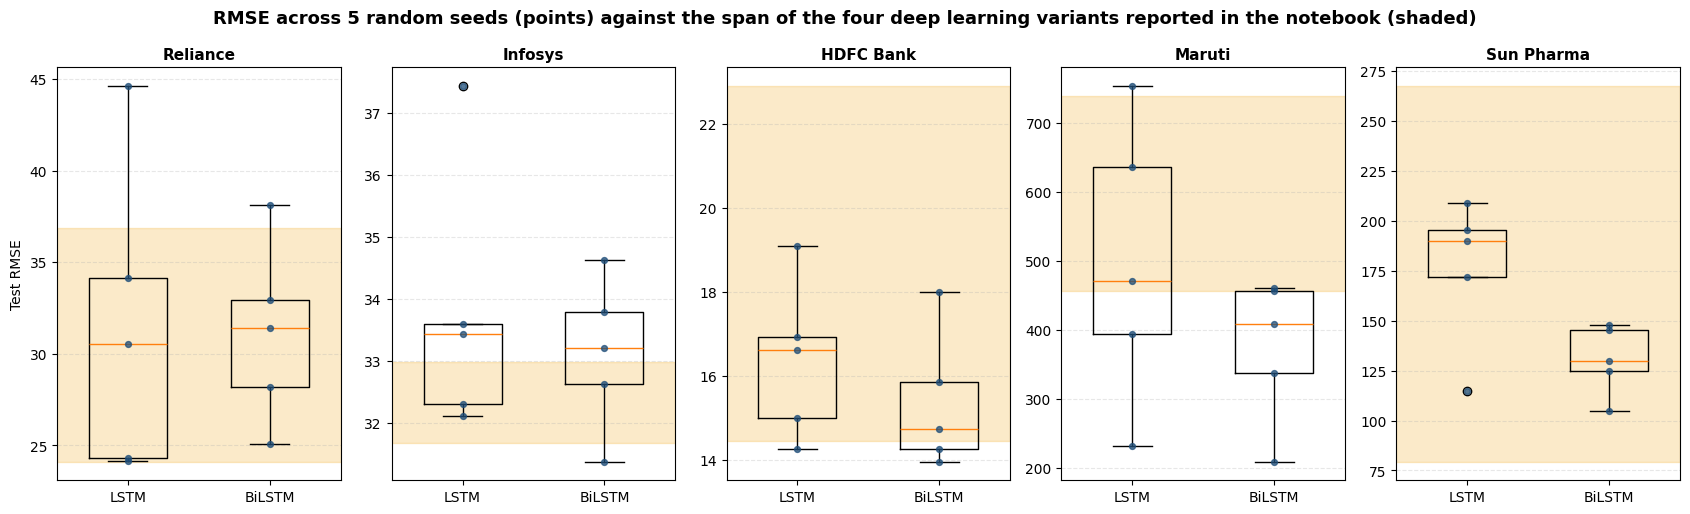

In [18]:
# min and max test RMSE across LSTM / tuned LSTM / BiLSTM / tuned BiLSTM, from the main notebook
NOTEBOOK_DL_SPREAD = {
    "Reliance":   (24.1218, 36.8961),
    "Infosys":    (31.6708, 32.9768),
    "HDFC Bank":  (14.4410, 22.8911),
    "Maruti":     (456.6650, 738.2819),
    "Sun Pharma": (79.4872, 267.3338),
}

# matplotlib renamed the boxplot label argument in 3.9; this keeps the cell working on both
import matplotlib
_LABEL_KW = "tick_labels" if tuple(int(v) for v in matplotlib.__version__.split(".")[:2]) >= (3, 9) else "labels"

fig, axes = plt.subplots(1, 5, figsize=(17, 5.2))
for ax, stock in zip(axes, STOCKS):
    sub = seed_df[seed_df.Stock == stock]
    data = [sub[sub.Model == m]["RMSE"].values for m in ("LSTM", "BiLSTM")]
    ax.boxplot(data, widths=0.55, **{_LABEL_KW: ["LSTM", "BiLSTM"]})
    for j, vals in enumerate(data, start=1):
        ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.75, color="#1f4e79", zorder=3)
    lo, hi = NOTEBOOK_DL_SPREAD[stock]
    ax.axhspan(lo, hi, color="#f0a30a", alpha=0.22)
    ax.set_title(stock, fontsize=11, fontweight="bold")
    ax.set_ylabel("Test RMSE" if stock == "Reliance" else "")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("RMSE across 5 random seeds (points) against the span of the four deep learning "
             "variants reported in the notebook (shaded)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig10_seed_stability.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 3. Experiment B: lookback sweep, 1 to 30 days (Figure 9, Table B7)

**The question this answers.** The main notebook used `window_size = 1`, so each recurrent network
saw a single day of OHLCV and had no sequence to remember. The obvious criticism is that the LSTM
and BiLSTM underperformed because they were handicapped, not because the target is hard. This sweeps
eight lookback lengths from 1 to 30 days and answers it directly.

Two design choices worth defending in the viva:

- **Eight windows, not thirty.** Repeats matter more than resolution for this question, and thirty
  single-seed points would mostly trace seed noise.
- **Three seeds per point.** Experiment A showed run-to-run RMSE moving by more than 100 per cent of
  the median on Maruti. A single fit per window would draw a curve out of that noise and call it a
  window effect. The figure therefore plots a median with a best-to-worst band, not one draw.

Both windows are run here on the same machine with the same TensorFlow build, so nothing is
confounded by library versions.

240 fits, roughly 30 minutes when `RERUN = True`, and results are written to CSV after every fit so
a crash still leaves usable partial results. Otherwise the saved results load instantly.

In [19]:
# a coarse grid, not every integer, for the reason given above
WINDOWS = [1, 2, 3, 5, 10, 15, 20, 30]
SWEEP_SEEDS = [16, 17, 18]

total = len(STOCKS) * len(WINDOWS) * len(ARCHITECTURES) * len(SWEEP_SEEDS)
_cached = RESULTS_DIR / "window_sweep_results.csv"

if not RERUN and _cached.exists():
    sweep_df = pd.read_csv(_cached)
    print(f"loaded {len(sweep_df)} of {total} fits from {_cached}")
    print("these are the runs behind Figure 9 in the report")
    print("set RERUN = True in the config cell to train from scratch instead")
else:
  rows = []
  done = 0

  for stock, csv_name in STOCKS.items():
      data = load_clean(csv_name)
      X_tr_s, X_te_s, y_tr_s, y_te_s, tscaler = split_and_scale(data)

      for window in WINDOWS:
          X_tr, y_tr = make_sequences(X_tr_s, y_tr_s, window)
          X_te, y_te = make_sequences(X_te_s, y_te_s, window)
          shape = (X_tr.shape[1], X_tr.shape[2])
          y_true = tscaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

          for arch, builder in ARCHITECTURES:
              for seed in SWEEP_SEEDS:
                  seed_everything(seed)
                  metrics = fit_and_score(builder, shape, X_tr, y_tr, X_te, y_true, tscaler)
                  metrics.update({
                      "Stock": stock, "Model": arch, "Window": window, "Seed": seed,
                      "Test Points": len(y_true),
                  })
                  rows.append(metrics)
                  done += 1
                  print(f"[{done:3d}/{total}] {stock:<11} {arch:<7} w={window:<3} seed={seed}  "
                        f"RMSE={metrics['RMSE']:10.4f}  MAPE={metrics['MAPE']:6.2f}%  "
                        f"R2={metrics['R2']:8.4f}", flush=True)

                  # written incrementally so a crash still leaves usable partial results
                  pd.DataFrame(rows).to_csv(OUT_DIR / "window_sweep_results.csv", index=False)

  sweep_df = pd.DataFrame(rows)[
      ["Stock", "Model", "Window", "Seed", "MAE", "MSE", "RMSE", "MAPE", "R2",
       "Epochs Run", "Test Points"]
  ]
  sweep_df.to_csv(OUT_DIR / "window_sweep_results.csv", index=False)
  print(f"\nwrote {OUT_DIR / 'window_sweep_results.csv'}")

loaded 240 of 240 fits from supplementary_results\window_sweep_results.csv
these are the runs behind Figure 9 in the report
set RERUN = True in the config cell to train from scratch instead


### Table B7: median RMSE by window

Each stock trades at a different price level, so RMSE is also expressed relative to that stock and
architecture's own one-day median. That relative column is what makes the five panels comparable and
what the report quotes.

In [20]:
sweep_summary = (
    sweep_df.groupby(["Stock", "Model", "Window"])["RMSE"]
            .agg(median="median", best="min", worst="max")
            .reset_index()
)
base = (sweep_summary[sweep_summary["Window"] == 1]
        .set_index(["Stock", "Model"])["median"].rename("w1_median"))
sweep_summary = sweep_summary.join(base, on=["Stock", "Model"])
sweep_summary["Median vs w=1 (%)"] = (
    (sweep_summary["median"] - sweep_summary["w1_median"]) / sweep_summary["w1_median"] * 100
)
sweep_summary.to_csv(OUT_DIR / "window_sweep_summary.csv", index=False)

print("Median RMSE by window (3 seeds each):")
print(sweep_summary.round(4).to_string(index=False))

Median RMSE by window (3 seeds each):
     Stock  Model  Window   median     best     worst  w1_median  Median vs w=1 (%)
 HDFC Bank BiLSTM       1  14.5235  14.0037   15.8459    14.5235             0.0000
 HDFC Bank BiLSTM       2  15.6191  15.3735   17.2571    14.5235             7.5438
 HDFC Bank BiLSTM       3  17.4182  16.3001   22.8123    14.5235            19.9312
 HDFC Bank BiLSTM       5  20.4335  19.9363   21.8161    14.5235            40.6928
 HDFC Bank BiLSTM      10  24.4930  16.9869   29.0188    14.5235            68.6434
 HDFC Bank BiLSTM      15  18.8005  16.1895   18.9087    14.5235            29.4488
 HDFC Bank BiLSTM      20  18.1500  17.8155   22.2965    14.5235            24.9696
 HDFC Bank BiLSTM      30  20.2682  19.4048   22.7829    14.5235            39.5543
 HDFC Bank   LSTM       1  14.2594  14.1121   14.7711    14.2594             0.0000
 HDFC Bank   LSTM       2  15.7451  15.7446   17.2403    14.2594            10.4194
 HDFC Bank   LSTM       3  17.4838  17

In [21]:
# the three claims the report makes about this experiment, recomputed rather than quoted
best = sweep_summary.loc[sweep_summary.groupby(["Stock", "Model"])["median"].idxmin()]
print("Best window per stock and architecture, by median RMSE:")
print(best[["Stock", "Model", "Window", "median"]].round(4).to_string(index=False))

n_one = int((best["Window"] == 1).sum())
print(f"\nwindow=1 is best in {n_one} of {len(best)} stock-architecture combinations")

long_worse = sweep_summary[(sweep_summary["Window"] >= 5)]
print(f"a lookback of 5 or more is worse than 1 in "
      f"{int((long_worse['Median vs w=1 (%)'] > 0).sum())} of {len(long_worse)} configurations")

w30 = sweep_summary[sweep_summary["Window"] == 30]
print(f"window=30 is worse than window=1 in {int((w30['Median vs w=1 (%)'] > 0).sum())} of "
      f"{len(w30)}, by {w30['Median vs w=1 (%)'].min():.1f}% to {w30['Median vs w=1 (%)'].max():.1f}%")

meta = {
    "tensorflow": tf.__version__,
    "seeds": SWEEP_SEEDS,
    "windows": WINDOWS,
    "fits": total,
    "note": "All windows and seeds run on one machine so the comparison is not confounded by "
            "library versions; repeats added because seed noise exceeds the window effect.",
}
_ = (OUT_DIR / "window_sweep_meta.json").write_text(json.dumps(meta, indent=1))

Best window per stock and architecture, by median RMSE:
     Stock  Model  Window   median
 HDFC Bank BiLSTM       1  14.5235
 HDFC Bank   LSTM       1  14.2594
   Infosys BiLSTM       1  32.8166
   Infosys   LSTM       1  32.1350
    Maruti BiLSTM       1 409.4811
    Maruti   LSTM       2 334.6574
  Reliance BiLSTM       1  26.2573
  Reliance   LSTM       1  27.2803
Sun Pharma BiLSTM       2  98.8671
Sun Pharma   LSTM       2 114.9595

window=1 is best in 7 of 10 stock-architecture combinations
a lookback of 5 or more is worse than 1 in 47 of 50 configurations
window=30 is worse than window=1 in 10 of 10, by 8.0% to 438.9%


### Figure 9

The band is the point of the figure. Without it a single-seed curve would look like a window effect,
when Experiment A shows run-to-run RMSE moving by more than 100 per cent of the median. Each stock
keeps its own y-axis because the five trade at different price levels.

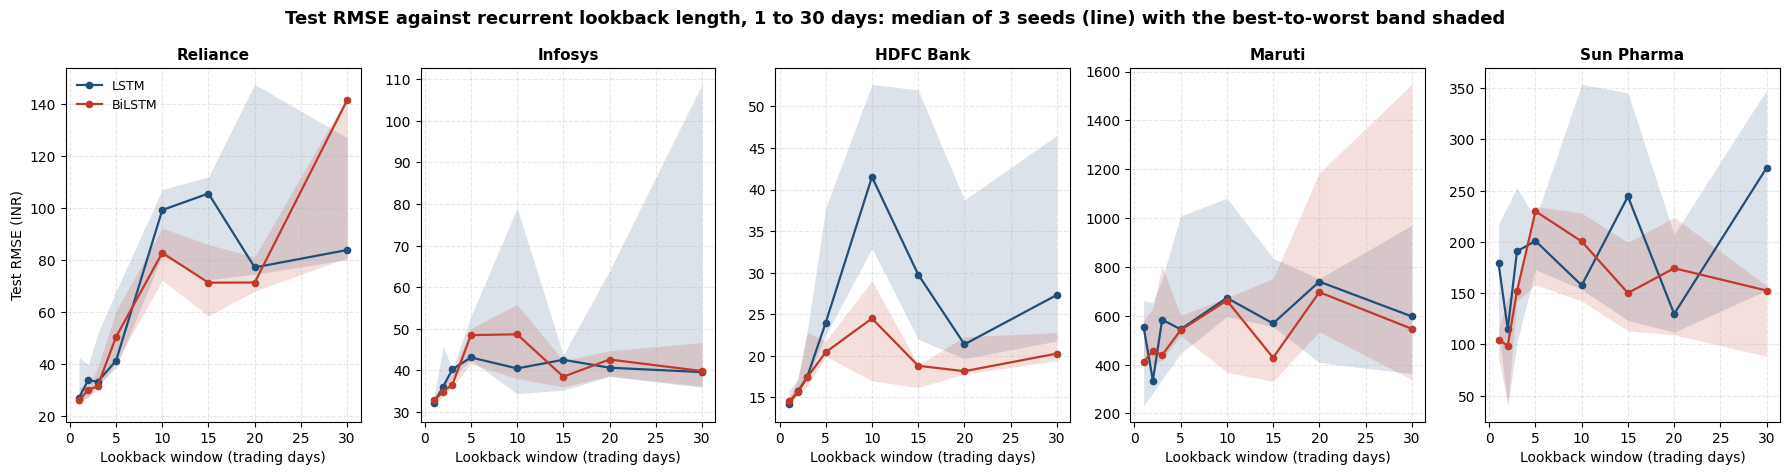

In [22]:
colours = {"LSTM": "#1f4e79", "BiLSTM": "#c0392b"}

fig, axes = plt.subplots(1, 5, figsize=(18, 4.8))
for ax, stock in zip(axes, STOCKS):
    for model in ("LSTM", "BiLSTM"):
        sub = sweep_summary[(sweep_summary.Stock == stock) &
                            (sweep_summary.Model == model)].sort_values("Window")
        ax.plot(sub["Window"], sub["median"], marker="o", markersize=4.5,
                linewidth=1.6, color=colours[model], label=model)
        ax.fill_between(sub["Window"], sub["best"], sub["worst"],
                        color=colours[model], alpha=0.16, linewidth=0)
    ax.set_title(stock, fontsize=11, fontweight="bold")
    ax.set_xlabel("Lookback window (trading days)")
    ax.set_ylabel("Test RMSE (INR)" if stock == "Reliance" else "")
    ax.grid(linestyle="--", alpha=0.3)
    if stock == "Reliance":
        ax.legend(fontsize=9, frameon=False)

fig.suptitle("Test RMSE against recurrent lookback length, 1 to 30 days: median of 3 seeds "
             "(line) with the best-to-worst band shaded",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "fig09_window_sweep.png", dpi=DPI, bbox_inches="tight")
plt.show()